In [17]:
import sys
sys.path.append('../src')

In [18]:
import sys
sys.path.append('../src')

In [19]:
from data_loader import get_data_generators

data_dir = "../data"

train_gen, val_gen = get_data_generators(data_dir)

Found 907 images belonging to 10 classes.
Found 222 images belonging to 10 classes.


In [20]:
print("Classes:", train_gen.class_indices)
print("Train samples:", train_gen.samples)
print("Validation samples:", val_gen.samples)

Classes: {'Avulsion fracture': 0, 'Comminuted fracture': 1, 'Fracture Dislocation': 2, 'Greenstick fracture': 3, 'Hairline Fracture': 4, 'Impacted fracture': 5, 'Longitudinal fracture': 6, 'Oblique fracture': 7, 'Pathological fracture': 8, 'Spiral Fracture': 9}
Train samples: 907
Validation samples: 222


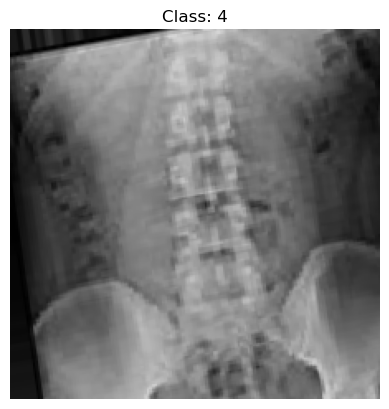

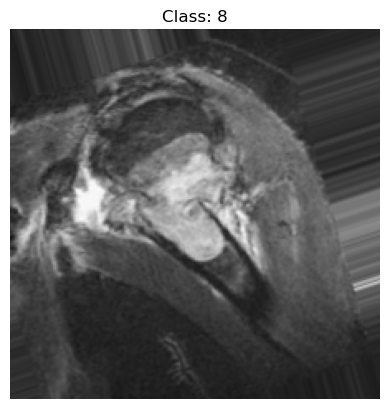

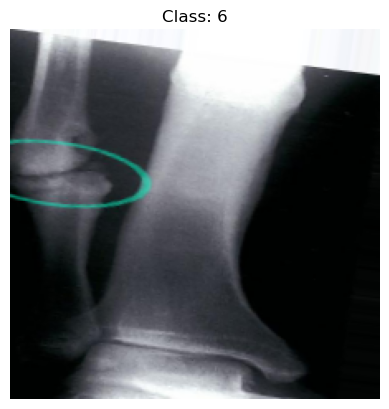

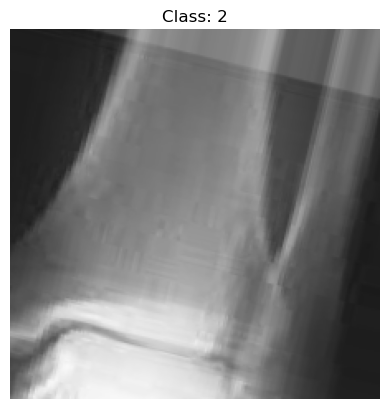

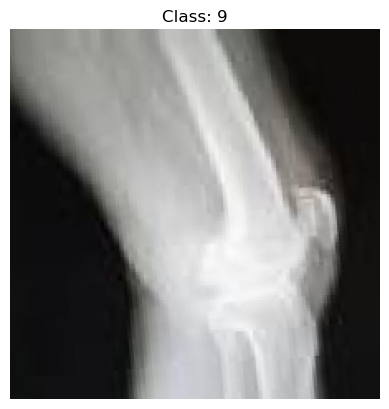

In [21]:
import matplotlib.pyplot as plt

# Get one batch
images, labels = next(train_gen)

# Plot first 5 images
for i in range(5):
    plt.imshow(images[i])
    plt.title(f"Class: {labels[i].argmax()}")
    plt.axis('off')
    plt.show()

In [25]:
from model import build_model

model = build_model()
model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_4[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,428,362 (9.26 MB)

 Trainable params: 167,818 (655.54 KB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [27]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Get class labels
classes = train_gen.classes

# Compute class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(classes),
    y=classes
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: np.float64(0.9161616161616162), 1: np.float64(0.7621848739495798), 2: np.float64(0.7256), 3: np.float64(0.9255102040816326), 4: np.float64(1.0191011235955056), 5: np.float64(1.3338235294117646), 6: np.float64(1.4171875), 7: np.float64(1.3338235294117646), 8: np.float64(0.8398148148148148), 9: np.float64(1.3144927536231885)}


In [28]:
from data_loader import get_data_generators
from model import build_model
from train import train_model

# Load data
train_gen, val_gen = get_data_generators("../data")

# Build model
model = build_model()

Found 907 images belonging to 10 classes.
Found 222 images belonging to 10 classes.


In [30]:
import tensorflow as tf

# Compile model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train model
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=25,
    class_weight=class_weights
)

Epoch 1/25
29/29 ━━━━━━━━━━━━━━━━━━━━ 28s 833ms/step - accuracy: 0.1036 - loss: 3.3864 - val_accuracy: 0.0946 - val_loss: 2.5997
Epoch 2/25
29/29 ━━━━━━━━━━━━━━━━━━━━ 22s 757ms/step - accuracy: 0.1301 - loss: 3.1514 - val_accuracy: 0.0946 - val_loss: 2.5223
Epoch 3/25
29/29 ━━━━━━━━━━━━━━━━━━━━ 22s 751ms/step - accuracy: 0.1268 - loss: 3.0456 - val_accuracy: 0.1171 - val_loss: 2.4664
Epoch 4/25
29/29 ━━━━━━━━━━━━━━━━━━━━ 22s 751ms/step - accuracy: 0.1400 - loss: 2.9384 - val_accuracy: 0.1261 - val_loss: 2.4309
Epoch 5/25
29/29 ━━━━━━━━━━━━━━━━━━━━ 23s 791ms/step - accuracy: 0.1621 - loss: 2.8235 - val_accuracy: 0.1351 - val_loss: 2.4115
Epoch 6/25
29/29 ━━━━━━━━━━━━━━━━━━━━ 22s 745ms/step - accuracy: 0.1698 - loss: 2.6450 - val_accuracy: 0.1441 - val_loss: 2.4034
Epoch 7/25
29/29 ━━━━━━━━━━━━━━━━━━━━ 22s 759ms/step - accuracy: 0.2106 - loss: 2.5978 - val_accuracy: 0.1712 - val_loss: 2.3953
Epoch 8/25
29/29 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.1951 - loss: 2.5417 - val_accurac

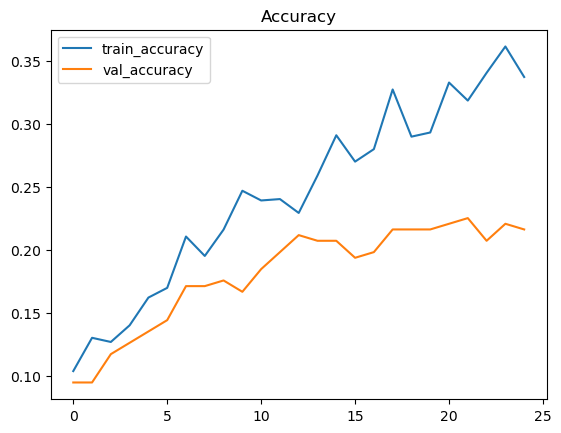

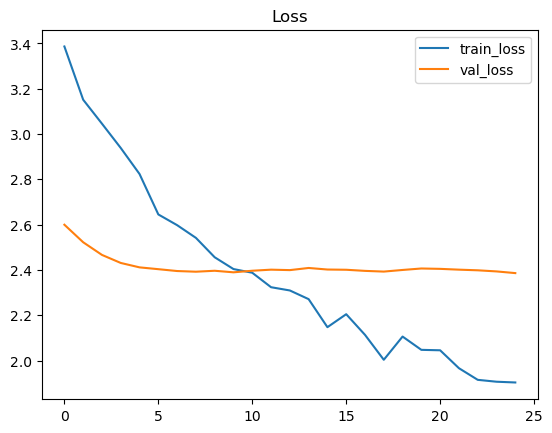

In [31]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'], label='train_accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.legend()
plt.title("Accuracy")
plt.show()

# Loss
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.title("Loss")
plt.show()

In [32]:
from evaluate import evaluate_model

7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 209ms/step

📄 Classification Report:

                       precision    recall  f1-score   support

    Avulsion fracture       0.16      0.25      0.19        24
  Comminuted fracture       0.33      0.14      0.20        29
 Fracture Dislocation       0.06      0.03      0.04        31
  Greenstick fracture       0.11      0.08      0.09        24
    Hairline Fracture       0.16      0.23      0.19        22
    Impacted fracture       0.15      0.12      0.14        16
Longitudinal fracture       0.08      0.12      0.10        16
     Oblique fracture       0.06      0.06      0.06        17
Pathological fracture       0.12      0.15      0.14        26
      Spiral Fracture       0.00      0.00      0.00        17

             accuracy                           0.12       222
            macro avg       0.12      0.12      0.11       222
         weighted avg       0.13      0.12      0.12       222



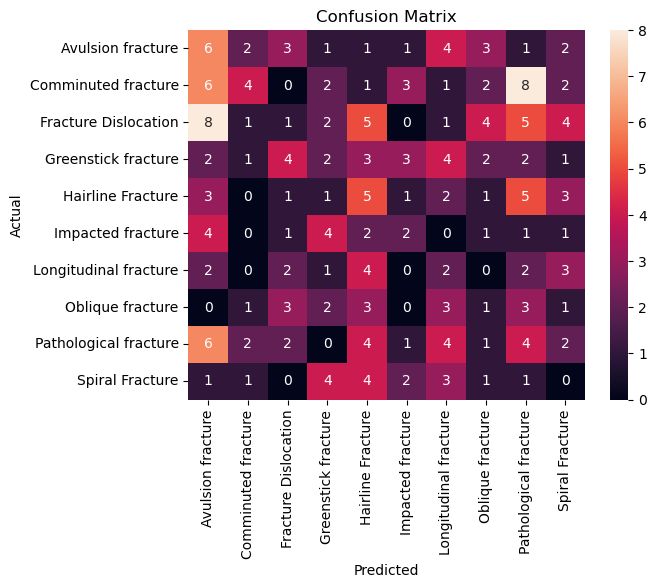

In [34]:
evaluate_model(model, val_gen)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 919ms/step


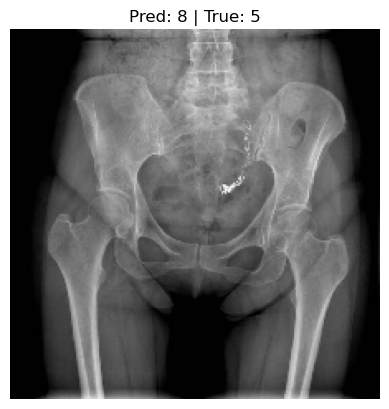

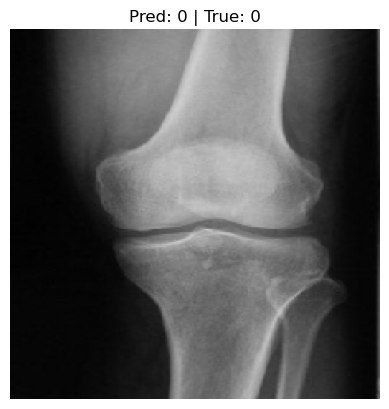

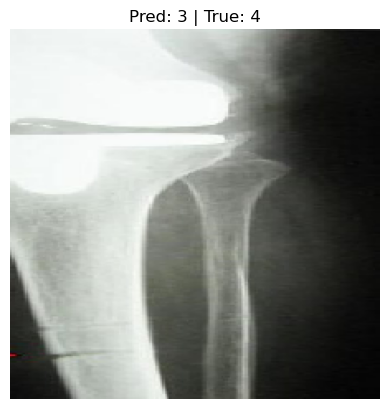

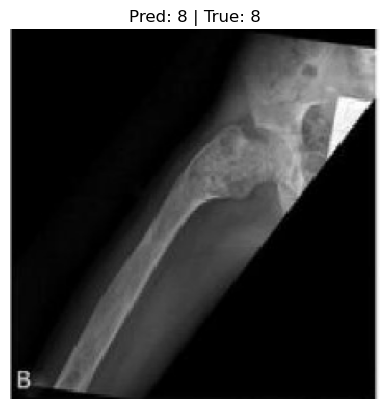

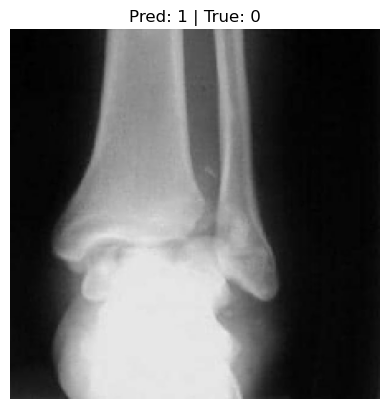

In [12]:
import matplotlib.pyplot as plt

images, labels = next(val_gen)
preds = model.predict(images)

for i in range(5):
    plt.imshow(images[i])
    plt.title(f"Pred: {preds[i].argmax()} | True: {labels[i].argmax()}")
    plt.axis('off')
    plt.show()

In [36]:
model.save("../models/final_model.h5")
print("Model saved successfully ✅")

Model saved successfully ✅


In [37]:
from predict import load_trained_model, predict_image

In [38]:
model = load_trained_model("../models/final_model.h5")

In [39]:
class_labels = list(train_gen.class_indices.keys())

In [41]:
img_path = r"C:\Users\LENOVO\Downloads\img.webp"  # change this

pred, conf = predict_image(model, img_path, class_labels)

print("Prediction:", pred)
print("Confidence:", conf)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 781ms/step
Prediction: Spiral Fracture
Confidence: 0.360984


In [45]:
import sys
sys.path.append('../src')

import importlib
import predict
importlib.reload(predict)

from predict import load_trained_model, predict_single_image, predict_folder

In [46]:
result = predict_single_image(model, img_path, class_labels)
print(result)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
{'image': 'C:\\Users\\LENOVO\\Downloads\\img.webp', 'prediction': 'Spiral Fracture', 'confidence': 0.361}
